In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
import pandas as pd
import numpy as np
import os

print("Libraries loaded successfully")


Libraries loaded successfully


In [3]:
# Path to CICIDS2017 folder
DATASET_PATH = "../datasets/CICIDS2017"

# Load all CSV files
csv_files = [f for f in os.listdir(DATASET_PATH) if f.endswith(".csv")]

print("CSV Files Found:", csv_files)

df_list = []

for file in csv_files:
    file_path = os.path.join(DATASET_PATH, file)
    print(f"Loading {file} ...")
    temp_df = pd.read_csv(file_path)
    df_list.append(temp_df)

# Merge into one DataFrame
df = pd.concat(df_list, ignore_index=True)

print("Merged Dataset Shape:", df.shape)
df.head()

CSV Files Found: ['Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv', 'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv', 'Friday-WorkingHours-Morning.pcap_ISCX.csv', 'Monday-WorkingHours.pcap_ISCX.csv', 'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv', 'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv', 'Tuesday-WorkingHours.pcap_ISCX.csv', 'Wednesday-workingHours.pcap_ISCX.csv']
Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv ...
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv ...
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv ...
Loading Monday-WorkingHours.pcap_ISCX.csv ...
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv ...
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv ...
Loading Tuesday-WorkingHours.pcap_ISCX.csv ...
Loading Wednesday-workingHours.pcap_ISCX.csv ...
Merged Dataset Shape: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [5]:
# Strip spaces from column names
df.columns = df.columns.str.strip()

# Check columns
print(df.columns)


Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [6]:
df['Label'].value_counts()


Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [7]:
# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with missing values
df.dropna(inplace=True)

print("After cleaning:", df.shape)


After cleaning: (2827876, 79)


In [8]:
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

df['Label'].value_counts()


Label
0    2271320
1     556556
Name: count, dtype: int64

In [9]:
df.to_csv("../datasets/CICIDS2017/cicids2017_cleaned.csv", index=False)
print("Cleaned dataset saved.")


Cleaned dataset saved.


In [10]:
X = df.drop(columns=['Label'])
y = df['Label']

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (2827876, 78)
Target shape: (2827876,)


In [11]:
import numpy as np

X = X.select_dtypes(include=[np.number])

print("Numeric features:", X.shape[1])


Numeric features: 78


In [12]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.0)
X_reduced = selector.fit_transform(X)

print("Reduced feature count:", X_reduced.shape[1])


Reduced feature count: 70


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (2262300, 78)
Test shape: (565576, 78)


In [14]:
X_train.to_csv("../datasets/CICIDS2017/X_train.csv", index=False)
X_test.to_csv("../datasets/CICIDS2017/X_test.csv", index=False)
y_train.to_csv("../datasets/CICIDS2017/y_train.csv", index=False)
y_test.to_csv("../datasets/CICIDS2017/y_test.csv", index=False)

print("Train/Test datasets saved successfully.")


Train/Test datasets saved successfully.


In [1]:
import pandas as pd

X_train = pd.read_csv("../datasets/CICIDS2017/X_train.csv")
X_test  = pd.read_csv("../datasets/CICIDS2017/X_test.csv")
y_train = pd.read_csv("../datasets/CICIDS2017/y_train.csv").squeeze()
y_test  = pd.read_csv("../datasets/CICIDS2017/y_test.csv").squeeze()

print(X_train.shape, X_test.shape)


(2262300, 78) (565576, 78)


In [2]:
from sklearn.utils import resample

# Combine X and y temporarily
train_df = X_train.copy()
train_df['Label'] = y_train

# Separate classes
normal = train_df[train_df['Label'] == 0]
attack = train_df[train_df['Label'] == 1]

# Subsample (adjust numbers if RAM allows)
normal_sample = normal.sample(n=200_000, random_state=42)
attack_sample = attack.sample(n=200_000, random_state=42)

train_sample = pd.concat([normal_sample, attack_sample])
train_sample = train_sample.sample(frac=1, random_state=42)  # shuffle

X_train_sample = train_sample.drop(columns=['Label'])
y_train_sample = train_sample['Label']

print("Training subset:", X_train_sample.shape)


Training subset: (400000, 78)


In [3]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_sample, y_train_sample)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [4]:
y_pred = rf_model.predict(X_test)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("Confusion Matrix:\n", cm)

Accuracy : 0.9988330480784192
Precision: 0.9949189082809271
Recall   : 0.9991734868970722
F1-score : 0.9970416588225802
Confusion Matrix:
 [[453697    568]
 [    92 111219]]


In [ ]:
TN, FP, FN, TP = cm.ravel()
false_positive_rate = FP / (FP + TN)

print("False Positive Rate:", false_positive_rate)

False Positive Rate: 0.0012503714792026681


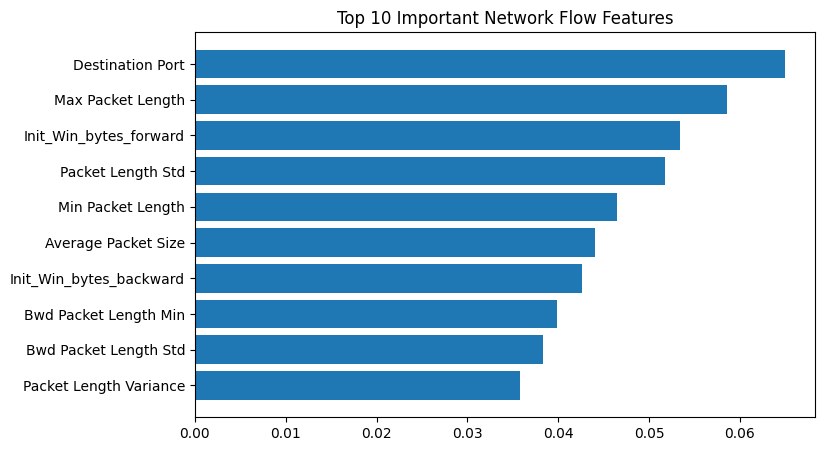

In [7]:
import numpy as np
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X_train.columns[indices])
plt.title("Top 10 Important Network Flow Features")
plt.show()


In [8]:
import joblib

joblib.dump(rf_model, "../models/random_forest_ids.pkl")
print("Random Forest model saved.")


Random Forest model saved.


In [1]:
import pandas as pd

X_train = pd.read_csv("../datasets/CICIDS2017/X_train.csv")
X_test  = pd.read_csv("../datasets/CICIDS2017/X_test.csv")
y_train = pd.read_csv("../datasets/CICIDS2017/y_train.csv").squeeze()
y_test  = pd.read_csv("../datasets/CICIDS2017/y_test.csv").squeeze()

print(X_train.shape, X_test.shape)


(2262300, 78) (565576, 78)


In [2]:
# Recreate the same balanced subset used for Random Forest
train_df = X_train.copy()
train_df['Label'] = y_train

normal = train_df[train_df['Label'] == 0]
attack = train_df[train_df['Label'] == 1]

normal_sample = normal.sample(n=200_000, random_state=42)
attack_sample = attack.sample(n=200_000, random_state=42)

train_sample = pd.concat([normal_sample, attack_sample]).sample(frac=1, random_state=42)

X_train_sample = train_sample.drop(columns=['Label'])
y_train_sample = train_sample['Label']

print("Training subset:", X_train_sample.shape)


Training subset: (400000, 78)


In [3]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_sample, y_train_sample)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [ ]:
y_pred_gb = gb_model.predict(X_test)


: 

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy_gb  = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb    = recall_score(y_test, y_pred_gb)
f1_gb        = f1_score(y_test, y_pred_gb)

cm_gb = confusion_matrix(y_test, y_pred_gb)

print("Accuracy :", accuracy_gb)
print("Precision:", precision_gb)
print("Recall   :", recall_gb)
print("F1-score :", f1_gb)
print("Confusion Matrix:\n", cm_gb)


Accuracy : 0.9947381076990537
Precision: 0.9788117989198172
Recall   : 0.9947983577543998
F1-score : 0.9867403314917127
Confusion Matrix:
 [[451868   2397]
 [   579 110732]]


In [6]:
TN, FP, FN, TP = cm_gb.ravel()
fpr_gb = FP / (FP + TN)

print("False Positive Rate:", fpr_gb)


False Positive Rate: 0.005276655696564781


In [7]:
import joblib

joblib.dump(gb_model, "../models/gradient_boosting_ids.pkl")
print("Gradient Boosting model saved.")


Gradient Boosting model saved.


In [1]:
import pandas as pd
import numpy as np

X_train = pd.read_csv("../datasets/CICIDS2017/X_train.csv")
y_train = pd.read_csv("../datasets/CICIDS2017/y_train.csv").squeeze()

X_test  = pd.read_csv("../datasets/CICIDS2017/X_test.csv")
y_test  = pd.read_csv("../datasets/CICIDS2017/y_test.csv").squeeze()


In [2]:
# Combine
train_df = X_train.copy()
train_df['Label'] = y_train

normal = train_df[train_df['Label'] == 0]
attack = train_df[train_df['Label'] == 1]

# MUCH smaller sample for LSTM
normal_sample = normal.sample(n=50_000, random_state=42)
attack_sample = attack.sample(n=50_000, random_state=42)

train_lstm = pd.concat([normal_sample, attack_sample]).sample(frac=1, random_state=42)

X_lstm = train_lstm.drop(columns=['Label']).values
y_lstm = train_lstm['Label'].values

print(X_lstm.shape, y_lstm.shape)


(100000, 78) (100000,)


In [3]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_lstm_scaled = scaler.fit_transform(X_lstm)


In [4]:
SEQUENCE_LENGTH = 10

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_lstm_scaled, y_lstm, SEQUENCE_LENGTH)

print(X_seq.shape, y_seq.shape)


(99990, 10, 78) (99990,)


In [5]:
from sklearn.model_selection import train_test_split

X_train_seq, X_val_seq, y_train_seq, y_val_seq = train_test_split(
    X_seq,
    y_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_seq
)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


c:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        36,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,673 (143.25 KB)

 Trainable params: 36,673 (143.25 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=256,
    validation_data=(X_val_seq, y_val_seq),
    verbose=1
)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.5004 - loss: 0.6941 - val_accuracy: 0.5001 - val_loss: 0.6946
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.5007 - loss: 0.6934 - val_accuracy: 0.5003 - val_loss: 0.6932
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5016 - loss: 0.6933 - val_accuracy: 0.5040 - val_loss: 0.6931
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5059 - loss: 0.6931 - val_accuracy: 0.4998 - val_loss: 0.6933
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5042 - loss: 0.6932 - val_accuracy: 0.5070 - val_loss: 0.6931


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred_prob = model.predict(X_val_seq)
y_pred = (y_pred_prob > 0.5).astype(int)
accuracy_lstm  = accuracy_score(y_val_seq, y_pred)
precision_lstm = precision_score(y_val_seq, y_pred)
recall_lstm    = recall_score(y_val_seq, y_pred)
f1_lstm        = f1_score(y_val_seq, y_pred)
cm_lstm = confusion_matrix(y_val_seq, y_pred)

print("Accuracy :", accuracy_lstm)
print("Precision:", precision_lstm)
print("Recall   :", recall_lstm)
print("F1-score :", f1_lstm)
print("Confusion Matrix:\n", cm_lstm)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Accuracy : 0.506950695069507
Precision: 0.5155056179775281
Recall   : 0.22944588917783557
F1-score : 0.3175526024363234
Confusion Matrix:
 [[7844 2156]
 [7704 2294]]


In [ ]:
TN, FP, FN, TP = cm_lstm.ravel()
fpr_lstm = FP / (FP + TN)

print("False Positive Rate:", fpr_lstm)

False Positive Rate: 0.2156


In [10]:
import pandas as pd

unsw_test = pd.read_csv("../datasets/UNSW-NB15/UNSW_NB15_testing-set.csv")

print(unsw_test.shape)
unsw_test.head()


(82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [11]:
unsw_test['label'].value_counts()


label
1    45332
0    37000
Name: count, dtype: int64

In [12]:
import joblib

# Load trained RF model
rf_model = joblib.load("../models/random_forest_ids.pkl")

# Get features used by the model
cicids_features = rf_model.feature_names_in_

print(len(cicids_features))


78


In [13]:
# Drop label columns
X_unsw = unsw_test.drop(columns=['label', 'attack_cat'], errors='ignore')

# Keep numeric only
X_unsw = X_unsw.select_dtypes(include=['int64', 'float64'])

# Keep only features present in CICIDS model
common_features = [f for f in cicids_features if f in X_unsw.columns]

X_unsw = X_unsw[common_features]

print("UNSW features used:", X_unsw.shape)


UNSW features used: (82332, 0)


In [14]:
y_unsw = unsw_test['label']


In [16]:
import pandas as pd
import numpy as np

unsw = pd.read_csv("../datasets/UNSW-NB15/UNSW_NB15_training-set.csv")
unsw_test = pd.read_csv("../datasets/UNSW-NB15/UNSW_NB15_testing-set.csv")

# Features and labels
X_unsw_train = unsw.drop(columns=['label', 'attack_cat'], errors='ignore')
y_unsw_train = unsw['label']

X_unsw_test = unsw_test.drop(columns=['label', 'attack_cat'], errors='ignore')
y_unsw_test = unsw_test['label']

# Keep numeric only
X_unsw_train = X_unsw_train.select_dtypes(include=[np.number])
X_unsw_test  = X_unsw_test.select_dtypes(include=[np.number])

print(X_unsw_train.shape, X_unsw_test.shape)


(175341, 40) (82332, 40)


In [17]:
from sklearn.ensemble import RandomForestClassifier

rf_unsw = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    n_jobs=-1,
    random_state=42,
    class_weight='balanced'
)

rf_unsw.fit(X_unsw_train, y_unsw_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred_unsw = rf_unsw.predict(X_unsw_test)

acc_unsw  = accuracy_score(y_unsw_test, y_pred_unsw)
prec_unsw = precision_score(y_unsw_test, y_pred_unsw)
rec_unsw  = recall_score(y_unsw_test, y_pred_unsw)
f1_unsw   = f1_score(y_unsw_test, y_pred_unsw)

cm_unsw = confusion_matrix(y_unsw_test, y_pred_unsw)

print("Accuracy :", acc_unsw)
print("Precision:", prec_unsw)
print("Recall   :", rec_unsw)
print("F1-score :", f1_unsw)
print("Confusion Matrix:\n", cm_unsw)


Accuracy : 0.5489360151581402
Precision: 0.6480364175006322
Recall   : 0.39568075531633284
F1-score : 0.49135061839996713
Confusion Matrix:
 [[27258  9742]
 [27395 17937]]


In [19]:
TN, FP, FN, TP = cm_unsw.ravel()
fpr_unsw = FP / (FP + TN)

print("False Positive Rate:", fpr_unsw)


False Positive Rate: 0.2632972972972973
